<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/Student_MobileNetV2_Pretrained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 · Student Candidate — MobileNetV2 (pretrained ImageNet)

Standard MobileNetV2 fine-tuned from ImageNet weights.
~3.4M parameters.

## Role in the 2×2 comparison

| | Scratch | Pretrained |
|---|---|---|
| **MobileNetV2** | notebook 06 | **← this notebook** |
| **MobileNetV3** | notebook 08 | notebook 09 |

**Claim this notebook helps answer:**
- *Initialization effect on V2:* Does pretraining improve MobileNetV2 on VWW?
  Compare this notebook's result against notebook 06 (same architecture, random init).

**Training protocol:**
- Phase 1 (epochs 1–9):  backbone frozen, classifier head only, lr=3e-4
- Phase 2 (epochs 10–25): full unfreeze at lr=1e-4


In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import (
    MobileNetV2_Scratch, MobileNetV2_Pretrained,
    MobileNetV3_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, STUDENT_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_multi_seed, plot_history,
)

device = setup_device(seed=41)


Device: cuda


In [3]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

## Standardized hyperparameters

All four student models use **identical training conditions** to ensure the
comparison is controlled — only architecture and initialization vary.

| Parameter | Scratch models | Pretrained models |
|-----------|---------------|-------------------|
| Batch size | 64 | 64 |
| Optimizer | Adam | Adam |
| Weight decay | 1e-4 | 1e-4 |
| Label smoothing | 0.1 | 0.1 |
| Augmentation | standard | standard |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Patience | 10 | 10 |
| Seeds | [41, 52, 63] | [41, 52, 63] |
| Max epochs | 50 | 25 |
| LR | 1e-3 | 3e-4 (head) → 1e-4 (full) |


In [4]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [5]:
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")


Train: 7000 | Val: 1500 | Batch: 64


In [6]:
results, best = train_multi_seed(
    model_fn     = MobileNetV2_Pretrained,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63],
    save_dir     = SAVE_DIR,
    name_prefix  = "mobilenetv2_pretrained",
    pretrained   = True,
    # Standard pretrained hyperparameters
    epochs          = 25,
    lr_phase1       = 3e-4,
    lr_phase2       = 1e-4,
    lr_phase3       = 1e-4,    # keep same LR — no third phase needed for V2
    phase2_epoch    = 10,
    phase3_epoch    = 999,     # disable phase 3
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 10,
)



Seed 41
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 189MB/s]


[P1] Epoch   1/25 | LR 0.000291 | Train 65.26% | Val 74.20% ✅
[P1] Epoch   2/25 | LR 0.000265 | Train 73.43% | Val 75.00% ✅
[P1] Epoch   3/25 | LR 0.000225 | Train 73.31% | Val 74.33%
[P1] Epoch   4/25 | LR 0.000176 | Train 74.81% | Val 75.00%
[P1] Epoch   5/25 | LR 0.000124 | Train 75.47% | Val 75.60% ✅
[P1] Epoch   6/25 | LR 0.000075 | Train 74.74% | Val 75.93% ✅
[P1] Epoch   7/25 | LR 0.000035 | Train 75.23% | Val 75.87%
[P1] Epoch   8/25 | LR 0.000009 | Train 75.23% | Val 75.47%
[P1] Epoch   9/25 | LR 0.000000 | Train 75.90% | Val 75.67%

── Phase 2: partial unfreeze (epoch 10) ──
[P2] Epoch  10/25 | LR 0.000100 | Train 75.13% | Val 74.87%
[P2] Epoch  11/25 | LR 0.000100 | Train 75.66% | Val 76.20% ✅
[P2] Epoch  12/25 | LR 0.000100 | Train 74.99% | Val 75.33%
[P2] Epoch  13/25 | LR 0.000100 | Train 75.63% | Val 75.73%
[P2] Epoch  14/25 | LR 0.000100 | Train 76.21% | Val 75.93%
[P2] Epoch  15/25 | LR 0.000100 | Train 75.07% | Val 75.67%
[P2] Epoch  16/25 | LR 0.000100 | Train 75.11%

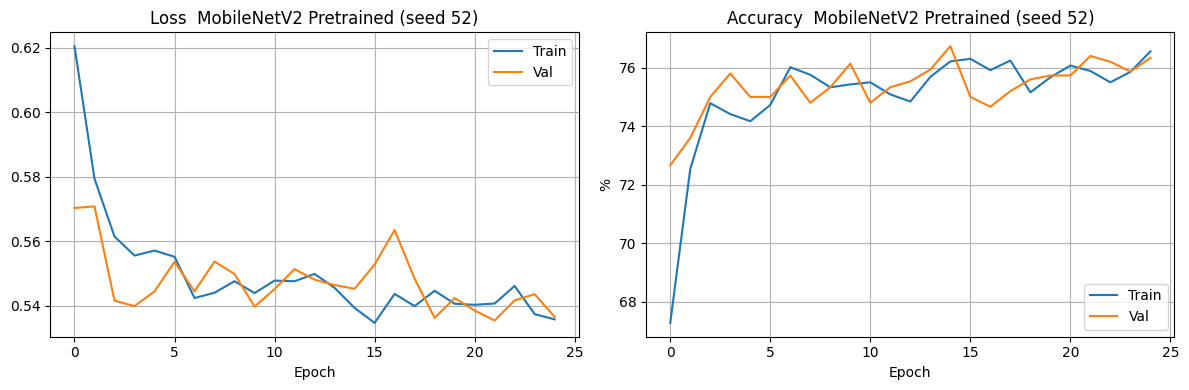

Best: 76.73% @ epoch 15  (5.9 min)

MobileNetV2 Pretrained
  Mean ± Std : 76.67% ± 0.09%
  Best       : 76.73% @ epoch 15 (seed 52)
  Checkpoint : /content/drive/My Drive/Colab Notebooks/mobilenetv2_pretrained_seed_52.pth


In [7]:
plot_history(best, title=f"MobileNetV2 Pretrained (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nMobileNetV2 Pretrained")
print(f"  Mean ± Std : {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
print(f"  Best       : {best['best_acc']*100:.2f}% @ epoch {best['best_epoch']} (seed {best['seed']})")
print(f"  Checkpoint : {best['save_path']}")


In [8]:
# ── Quick parameter/size summary ────────────────────────────────────
m = MobileNetV2_Pretrained()
total, _ = count_params(m)
size = model_size_mb(m)
print(f"MobileNetV2 Pretrained  |  Params: {total/1e6:.2f}M  |  Size: {size:.2f}MB")
print(f"Compare to nb 06 (MobileNetV2 Scratch) to isolate initialization effect.")


MobileNetV2 Pretrained  |  Params: 2.23M  |  Size: 9.15MB
Compare to nb 06 (MobileNetV2 Scratch) to isolate initialization effect.
